# Current Definition

The gradient of a given function $\nabla f$ with parameters $(x, y)$ is currently defined as

$$
\begin{aligned}
\nabla f &= \frac{\partial f}{\partial x} + \frac{\partial f}{\partial y} \\
         &= \frac{f(x) - f(\Delta x_i)}{2 \Delta x_i} + \frac{f(y) - f(\Delta y_i)}{2 \Delta y_i} \\
         &= a_x + a_y .
\end{aligned}
$$


# Our Idea

We propose to modify the gradient derivative by introducing coupling of the individual components
$$
\begin{aligned}
\nabla f &= \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right) \\
         &= \left( \frac{f(x) - f(\Delta x_i)}{2 \Delta x_i}, \frac{f(y) - f(\Delta y_i)}{2 \Delta y_i} \right).
\end{aligned}
$$
Where the component sums of the gradient are not summed but rather left independently.

# Theory

We define a coupling frequency for the derivative, $\nu(\frac{\partial f}{\partial x})_{y}$, for a given function $f(x, y)$, defined over a discrete iteration index $i \in \mathbb{Z}_{>0}$, whereby the partial gradients for $x + e_i, y$ and $x, y + e_i$ remain the same but are swapped at a particular sequence of increments proportional to the value of $\nu(\frac{\partial f}{\partial x})_{y}$.

Define a **swap indicator** $s_i \in \{0,1\}$:

- $s_i = 1$ if the **updates are exchanged** at step $i$ (i.e., we update $x$ using $G_y^{(i)}$ and $y$ using $G_x^{(i)}$).
- $s_i = 0$ otherwise (standard update).


The empirical swap frequency over $N$ steps is:
$$
\nu_N = \frac{1}{N} \sum_{i=1}^{N} s_i.
$$

We define the **coupling coefficient** as this frequency:

$$
\boxed{C\!\left(\frac{\partial f}{\partial x}\right)_{\!y} := \nu_N}
$$

Thus, a larger $C$ means swaps occur more often (stronger/faster coupling), and a smaller $C$ means swaps occur less often (weaker/slower coupling).

In [1]:
# Current code definition

def numerical_gradient(f, x, eps=1e-6):
    grad = np.zeros_like(x)
    for idx in range(len(x)):
        plus = x.copy()
        minus = x.copy()
        plus[idx] += eps
        minus[idx] -= eps
        grad[idx] = (f(plus) - f(minus)) / (2.0 * eps)
    return grad


## Examples

### Example 1: Computing $\nu_N$ from a swap-indicator array

Suppose over $N = 10$ steps we record the swap indicators as an array:

$$
\mathbf{s} = [\,0,\ 1,\ 0,\ 0,\ 1,\ 0,\ 1,\ 0,\ 0,\ 1\,]
$$

The sum of the entries is $\sum_{i=1}^{10} s_i = 4$, so the empirical swap frequency is

$$
\nu_{10} = \frac{4}{10} = 0.4,
\qquad
C\!\left(\frac{\partial f}{\partial x}\right)_{\!y} = 0.4.
$$

Swaps occurred on 4 of the 10 steps — a moderate coupling.

### Example 2: Comparing strong and weak coupling

Two runs of the same length $N = 10$:

$$
\mathbf{s}^{(A)} = [\,1,\ 1,\ 0,\ 1,\ 1,\ 1,\ 0,\ 1,\ 1,\ 1\,]
\quad\Rightarrow\quad
\nu_{10}^{(A)} = \frac{8}{10} = 0.8
$$

$$
\mathbf{s}^{(B)} = [\,0,\ 0,\ 0,\ 1,\ 0,\ 0,\ 0,\ 0,\ 0,\ 0\,]
\quad\Rightarrow\quad
\nu_{10}^{(B)} = \frac{1}{10} = 0.1
$$

Run $A$ has $C = 0.8$ (strong/fast coupling: the gradients of $x$ and $y$ are exchanged on most steps), while run $B$ has $C = 0.1$ (weak/slow coupling: the standard update dominates).

A **periodic** swap schedule is a special case. Swapping every third step,

$$
\mathbf{s} = [\,0,\ 0,\ 1,\ 0,\ 0,\ 1,\ 0,\ 0,\ 1,\ \dots\,],
$$

gives $\nu_N \to \tfrac{1}{3}$ as $N \to \infty$, so the coupling coefficient recovers the swap period: $C = 1/3$ corresponds to one exchange per three iterations.

### Example 3: A full trajectory with $f(x, y) = x^2 y$

Take $f(x, y) = x^2 y$, so the partial gradients are

$$
G_x^{(i)} = \frac{\partial f}{\partial x} = 2 x_i y_i,
\qquad
G_y^{(i)} = \frac{\partial f}{\partial y} = x_i^2.
$$

Use a gradient-descent-style increment with step size $\eta = 0.1$:

- **Standard step** ($s_i = 0$): $\quad x_{i+1} = x_i - \eta\, G_x^{(i)}, \quad y_{i+1} = y_i - \eta\, G_y^{(i)}$
- **Swapped step** ($s_i = 1$): $\quad x_{i+1} = x_i - \eta\, G_y^{(i)}, \quad y_{i+1} = y_i - \eta\, G_x^{(i)}$

Starting from $(x_1, y_1) = (1.0,\ 2.0)$ with swap array $\mathbf{s} = [\,0,\ 1,\ 0,\ 1,\ 0\,]$ over $N = 5$ steps, the trajectory arrays are:

| $i$ | $x_i$ | $y_i$ | $G_x^{(i)} = 2x_i y_i$ | $G_y^{(i)} = x_i^2$ | $s_i$ | update used for $x$ | update used for $y$ |
|----:|--------:|--------:|-------:|-------:|:---:|:---:|:---:|
| 1 | 1.0000 | 2.0000 | 4.0000 | 1.0000 | 0 | $G_x$ | $G_y$ |
| 2 | 0.6000 | 1.9000 | 2.2800 | 0.3600 | 1 | $G_y$ | $G_x$ |
| 3 | 0.5640 | 1.6720 | 1.8860 | 0.3181 | 0 | $G_x$ | $G_y$ |
| 4 | 0.3754 | 1.6402 | 1.2314 | 0.1409 | 1 | $G_y$ | $G_x$ |
| 5 | 0.3613 | 1.5170 | 1.0962 | 0.1305 | 0 | $G_x$ | $G_y$ |
| 6 | 0.2517 | 1.5040 | — | — | — | — | — |

Collected as arrays:

$$
\mathbf{x} = [\,1.0000,\ 0.6000,\ 0.5640,\ 0.3754,\ 0.3613,\ 0.2517\,]
$$
$$
\mathbf{y} = [\,2.0000,\ 1.9000,\ 1.6720,\ 1.6402,\ 1.5170,\ 1.5040\,]
$$
$$
\mathbf{s} = [\,0,\ 1,\ 0,\ 1,\ 0\,]
$$

The coupling coefficient for this run is

$$
C\!\left(\frac{\partial f}{\partial x}\right)_{\!y} = \nu_5 = \frac{0 + 1 + 0 + 1 + 0}{5} = \frac{2}{5} = 0.4.
$$

Note how the swapped steps ($i = 2$ and $i = 4$) apply the *small* gradient $G_y$ to $x$ and the *large* gradient $G_x$ to $y$, visibly slowing the decay of $x$ and accelerating the decay of $y$ relative to the standard steps.

### Example 4: Computing $\nu_N$ with NumPy

In [2]:
import numpy as np

s = np.array([0, 1, 0, 0, 1, 0, 1, 0, 0, 1])  # swap indicators
nu_N = s.mean()                                # nu_N = s.sum() / len(s)
print(nu_N)                                    # 0.4

0.4


And the trajectory of Example 3 as a vectorized update:

In [3]:
import numpy as np

eta = 0.1
s = np.array([0, 1, 0, 1, 0])
x, y = np.empty(len(s) + 1), np.empty(len(s) + 1)
x[0], y[0] = 1.0, 2.0

for i, swap in enumerate(s):
    Gx, Gy = 2 * x[i] * y[i], x[i] ** 2
    if swap:                       # exchanged update
        x[i + 1] = x[i] - eta * Gy
        y[i + 1] = y[i] - eta * Gx
    else:                          # standard update
        x[i + 1] = x[i] - eta * Gx
        y[i + 1] = y[i] - eta * Gy

C = s.mean()                       # coupling coefficient: 0.4
print(s)

[0 1 0 1 0]


### Example 5: How the gradients themselves change with the coupling

To see the effect of the coupling coefficient directly on the gradients, we run the same dynamics as Example 3 ($f(x,y) = x^2 y$, $\eta = 0.1$, start $(1.0,\ 2.0)$) for $N = 40$ steps under four **periodic swap schedules**, each realizing a different coupling coefficient:

| Schedule | Swap array pattern | $C = \nu_{40}$ |
|---|---|:---:|
| no swaps | $\mathbf{s} = [\,0,\ 0,\ 0,\ 0,\ \dots\,]$ | $0$ |
| swap every 4th step | $\mathbf{s} = [\,0,\ 0,\ 0,\ 1,\ 0,\ 0,\ 0,\ 1,\ \dots\,]$ | $0.25$ |
| swap every 2nd step | $\mathbf{s} = [\,0,\ 1,\ 0,\ 1,\ 0,\ 1,\ \dots\,]$ | $0.5$ |
| swap every step | $\mathbf{s} = [\,1,\ 1,\ 1,\ 1,\ \dots\,]$ | $1$ |

Each panel below plots the gradient trajectories $G_x^{(i)} = 2 x_i y_i$ and $G_y^{(i)} = x_i^2$ against the iteration index for one value of $C$:

![Gradient trajectories of f(x,y) = x²y under increasing coupling](coupling-frequency-gradients.png)

Reading left to right:

- **$C = 0$ (uncoupled):** each variable consumes its own gradient. The large $G_x$ drives $x \to 0$ within about 10 steps, and since both gradients contain a factor of $x$, both collapse with it. The endpoint is $(x, y) \approx (0.000,\ 1.841)$ — $y$ barely moves.
- **$C = 0.25$:** every 4th step exchanges the updates, producing the visible kinks in $G_x$. During a swapped step $x$ only absorbs the small $G_y$, so the collapse of $x$ is delayed and the gradients persist slightly longer. Endpoint $\approx (0.000,\ 1.725)$.
- **$C = 0.5$:** alternating swaps turn the decay of $G_x$ into a staircase — every other step $x$ is shielded from its own large gradient while $y$ absorbs it instead. The gradients stay non-negligible for roughly twice as long, and $y$ now decays substantially: endpoint $\approx (0.002,\ 1.243)$.
- **$C = 1$ (fully coupled):** the updates are exchanged on every step, so $x$ only ever feels the small $G_y$ and $y$ only ever feels the large $G_x$. Both gradients now decay slowly and smoothly, and the roles of the variables invert — it is $y$ that is driven toward zero: endpoint $\approx (0.194,\ 0.068)$.

The trend is monotone in $C$: **increasing the coupling frequency redirects the large gradient $G_x$ away from $x$ and into $y$**, which both prolongs the life of the gradients and shifts the decay burden from $x$ to $y$.

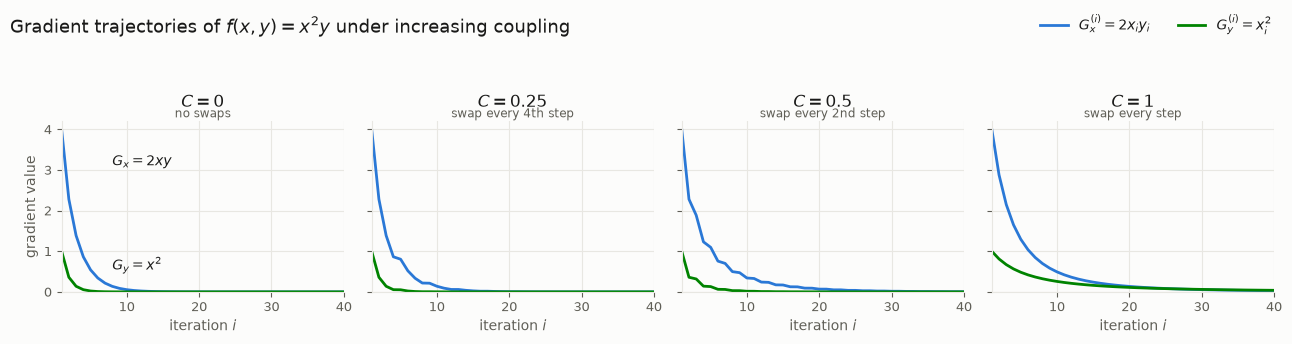

In [4]:
import matplotlib.pyplot as plt
import numpy as np

SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#1a1a19"
TEXT_SECONDARY = "#5f5e56"
GRID = "#e8e7e2"
C_GX = "#2a78d6"   # blue: G_x
C_GY = "#008300"   # green: G_y

N, ETA = 40, 0.1
X0, Y0 = 1.0, 2.0


def run(period):
    """period=0: never swap. period=p: swap on steps i with i % p == 0."""
    x, y = X0, Y0
    s = np.zeros(N, dtype=int)
    Gx, Gy = np.empty(N), np.empty(N)
    for i in range(1, N + 1):
        Gx[i - 1], Gy[i - 1] = 2 * x * y, x * x
        s[i - 1] = int(period > 0 and i % period == 0)
        if s[i - 1]:                       # exchanged update
            x, y = x - ETA * Gy[i - 1], y - ETA * Gx[i - 1]
        else:                              # standard update
            x, y = x - ETA * Gx[i - 1], y - ETA * Gy[i - 1]
    return Gx, Gy, s.mean()               # s.mean() is C for this run


panels = [(0, "no swaps"), (4, "swap every 4th step"),
          (2, "swap every 2nd step"), (1, "swap every step")]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
fig.patch.set_facecolor(SURFACE)

for ax, (period, sched) in zip(axes, panels):
    Gx, Gy, C = run(period)
    i = np.arange(1, N + 1)
    ax.set_facecolor(SURFACE)
    ax.plot(i, Gx, color=C_GX, lw=2)
    ax.plot(i, Gy, color=C_GY, lw=2)
    ax.set_title(f"$C = {C:g}$", fontsize=12, color=TEXT_PRIMARY, pad=10)
    ax.text(0.5, 1.005, sched, transform=ax.transAxes, ha="center",
            va="bottom", fontsize=8.5, color=TEXT_SECONDARY)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=9)
    ax.set_xlabel("iteration $i$", fontsize=10, color=TEXT_SECONDARY)
    ax.set_xlim(1, N)

axes[0].set_ylabel("gradient value", fontsize=10, color=TEXT_SECONDARY)
axes[0].set_ylim(bottom=0)

# direct labels on the first panel; shared legend for the whole figure
Gx0, Gy0, _ = run(0)
axes[0].annotate("$G_x = 2xy$", xy=(4, Gx0[3]), xytext=(8, 3.1),
                 fontsize=10, color=TEXT_PRIMARY)
axes[0].annotate("$G_y = x^2$", xy=(4, Gy0[3]), xytext=(8, 0.55),
                 fontsize=10, color=TEXT_PRIMARY)
fig.legend(handles=[plt.Line2D([], [], color=C_GX, lw=2,
                               label="$G_x^{(i)} = 2 x_i y_i$"),
                    plt.Line2D([], [], color=C_GY, lw=2,
                               label="$G_y^{(i)} = x_i^2$")],
           loc="upper right", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.99, 1.02), labelcolor=TEXT_PRIMARY)
fig.suptitle("Gradient trajectories of $f(x,y)=x^2y$ under increasing coupling",
             x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)

fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig("coupling-frequency-gradients.png", dpi=160,
            facecolor=SURFACE, bbox_inches="tight")

In [6]:
import pandas as pd

periods = [0, 4, 2, 1]
C_vals  = [0, 0.25, 0.5, 1]
data = {}
for per, C in zip(periods, C_vals):
    Gx, Gy, _ = run(per)
    data[f'C={C} Gx'] = Gx
    data[f'C={C} Gy'] = Gy

df = pd.DataFrame(data, index=np.arange(1, N+1))
# print(df.head(10).to_string())   # first 10 iterations
print(df.to_string()) # for all 40

          C=0 Gx        C=0 Gy  C=0.25 Gx     C=0.25 Gy  C=0.5 Gx  C=0.5 Gy    C=1 Gx    C=1 Gy
1   4.000000e+00  1.000000e+00   4.000000  1.000000e+00  4.000000  1.000000  4.000000  1.000000
2   2.280000e+00  3.600000e-01   2.280000  3.600000e-01  2.280000  0.360000  2.880000  0.810000
3   1.386816e+00  1.383840e-01   1.386816  1.383840e-01  1.886016  0.318096  2.149056  0.670761
4   8.633535e-01  5.443748e-02   0.863353  5.443748e-02  1.231450  0.140924  1.649863  0.565390
5   5.422845e-01  2.160402e-02   0.803863  5.192686e-02  1.096235  0.130542  1.296348  0.483560
6   3.418114e-01  8.603416e-03   0.518756  2.175283e-02  0.757056  0.063344  1.038447  0.418646
7   2.157492e-01  3.430851e-03   0.335880  9.141805e-03  0.700854  0.060196  0.845570  0.366224
8   1.362549e-01  1.368893e-03   0.217775  3.847077e-03  0.498540  0.030717  0.698251  0.323240
9   8.606977e-02  5.463001e-04   0.213739  3.799502e-03  0.472634  0.029650  0.583669  0.287530
10  5.437353e-02  2.180373e-04   0.13959